# Illusion Object Detection Comparison

In [1]:
!pip install -q torch torchvision transformers pillow

In [2]:
from PIL import Image
import torch
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import vit_b_16, ViT_B_16_Weights
from transformers import CLIPProcessor, CLIPModel

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.3) or chardet (7.0.1)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


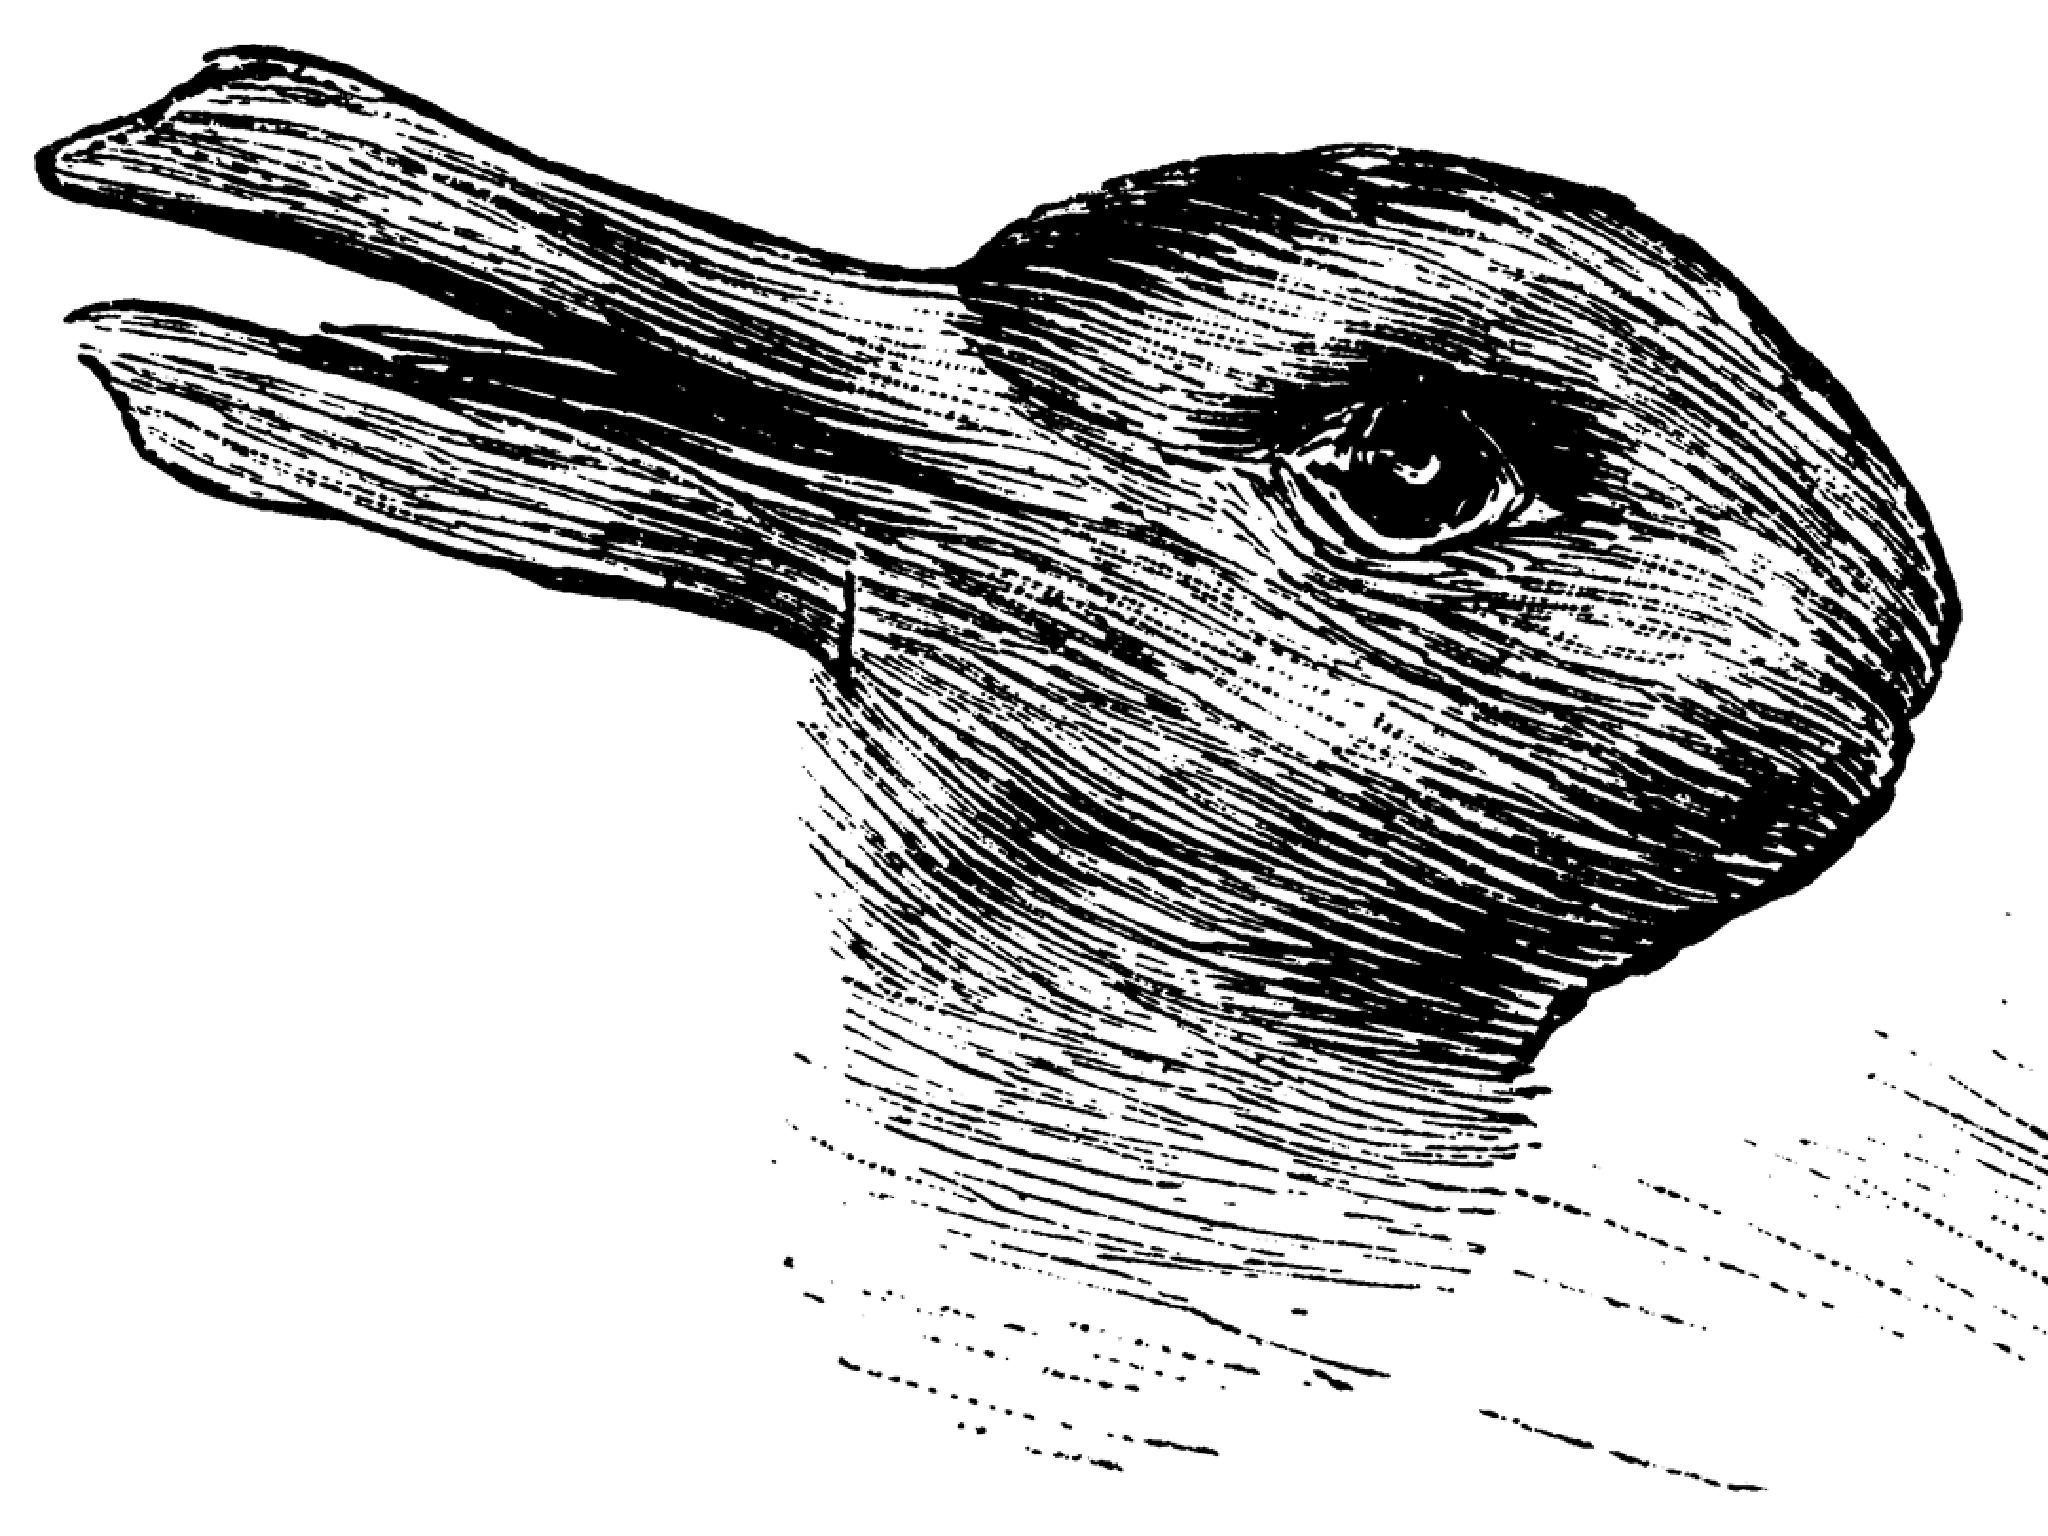

In [3]:
image_path = "/Users/anikapandey/computerVisionFinal/duck_rabbit"
image = Image.open(image_path).convert("RGB")
image

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [5]:
resnet_weights = ResNet50_Weights.DEFAULT
resnet = resnet50(weights=resnet_weights).to(device).eval()
resnet_preprocess = resnet_weights.transforms()
resnet_classes = resnet_weights.meta["categories"]

efficientnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet = efficientnet_b0(weights=efficientnet_weights).to(device).eval()
efficientnet_preprocess = efficientnet_weights.transforms()
efficientnet_classes = efficientnet_weights.meta["categories"]

vit_weights = ViT_B_16_Weights.DEFAULT
vit = vit_b_16(weights=vit_weights).to(device).eval()
vit_preprocess = vit_weights.transforms()
vit_classes = vit_weights.meta["categories"]

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [6]:
def top1_torchvision(model, preprocess, classes, image):
    x = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        pred_idx = logits.argmax(dim=1).item()
    return classes[pred_idx]

def top1_clip(model, processor, image, candidate_texts):
    inputs = processor(text=candidate_texts, images=image, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        scores = outputs.logits_per_image.softmax(dim=1)
        pred_idx = scores.argmax(dim=1).item()
    return candidate_texts[pred_idx], scores[0, pred_idx].item()

In [7]:
clip_candidates = [
    "a photo of a duck",
    "a photo of a rabbit",
    "a photo of a hare",
    "a photo of a bird",
    "a photo of an animal"
]

results = {}
results["ResNet50"] = top1_torchvision(resnet, resnet_preprocess, resnet_classes, image)
results["EfficientNet-B0"] = top1_torchvision(efficientnet, efficientnet_preprocess, efficientnet_classes, image)
results["ViT-B/16"] = top1_torchvision(vit, vit_preprocess, vit_classes, image)
clip_label, clip_conf = top1_clip(clip_model, clip_processor, image, clip_candidates)
results["CLIP (candidate labels)"] = f"{clip_label} (p={clip_conf:.3f})"

for model_name, pred in results.items():
    print(f"{model_name}: {pred}")

ResNet50: beaver
EfficientNet-B0: paintbrush
ViT-B/16: padlock
CLIP (candidate labels): a photo of a hare (p=0.495)
